In [1]:
suppressMessages({
library(DESeq2)
library(tidyverse)
library(pheatmap)
library(ggplot2)
library(ggrepel)
library(clusterProfiler)
library(org.Mm.eg.db)
library(openxlsx)
library(venn)   
library(ggrepel)
library(dplyr)
})

In [2]:
# 1. 读取文件
gene_counts <- read_csv("/media/desk16/iy11913/test/01_Bulk_RNAseq_script/06_GeneExpression/gene_expression_matrix.csv")
gene_TPM <- read_csv("/media/desk16/iy11913/test/01_Bulk_RNAseq_script/06_GeneExpression/gene_expression_TPM.csv")

Rows: 56941 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): gene_id
dbl (8): WT-testis-1, WT-testis-2, C6-KO-testis-2, C6-KO-testis-1, C26-DKO-t...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 56941 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): gene_id
dbl (8): WT-testis-1, WT-testis-2, C6-KO-testis-2, C6-KO-testis-1, C26-DKO-t...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
# 2. 数据过滤
gene_counts <- gene_counts[apply(gene_counts > 10, 1, all),]
gene_TPM <- gene_TPM[apply(gene_TPM > 1, 1, all), ]

In [4]:
head(gene_counts)

gene_id,WT-testis-1,WT-testis-2,C6-KO-testis-2,C6-KO-testis-1,C26-DKO-testis-2,C2-KO-testis-1,C2-KO-testis-2,C26-DKO-testis-1
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000000001,1363,1344,1811,2364,1914,1785,2019,2217
ENSMUSG00000000028,707,772,767,742,824,702,718,915
ENSMUSG00000000037,738,745,845,1104,987,797,949,1007
ENSMUSG00000000049,1010,846,743,671,886,819,873,907
ENSMUSG00000000056,155,159,218,211,194,178,206,209
ENSMUSG00000000058,42,67,57,176,74,81,112,93


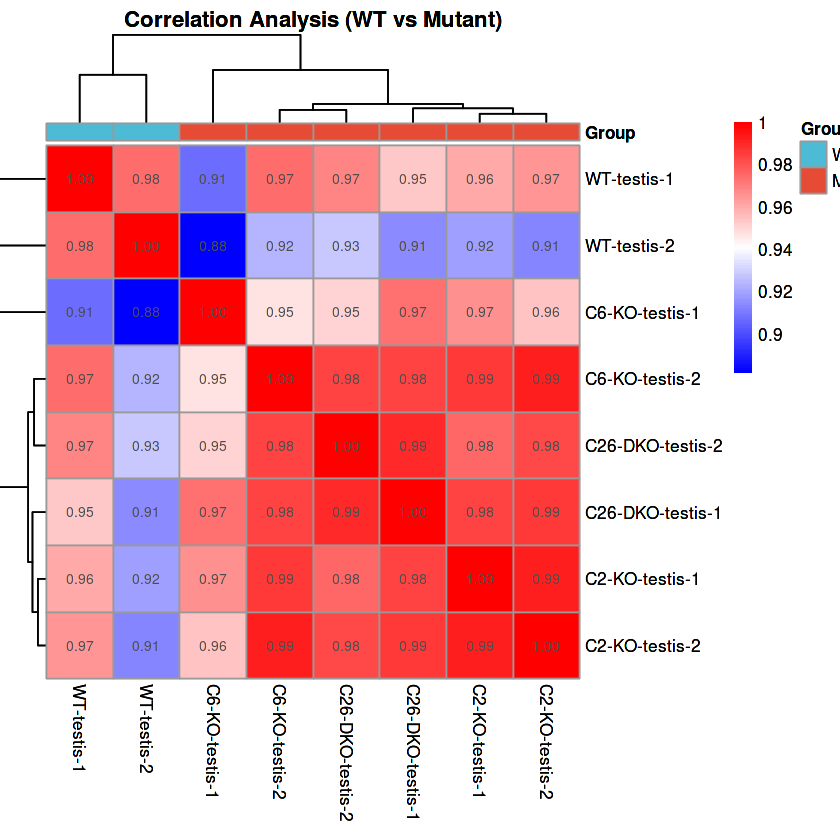

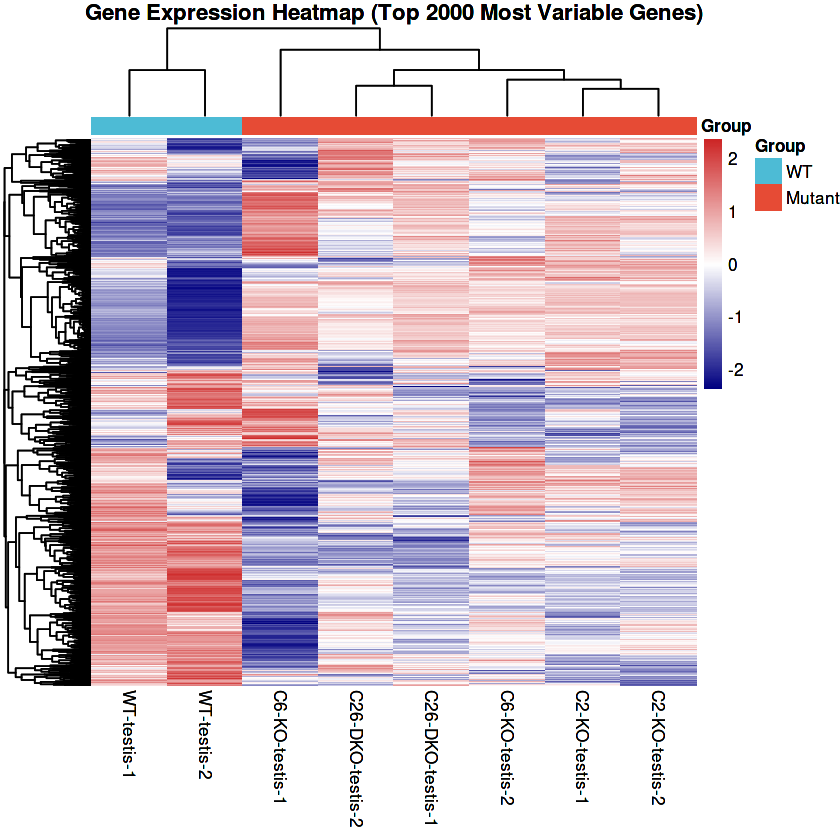

In [5]:
# 3. 计算相关性热图

# 加载库
library(pheatmap)

# 3.1. 相关性热图
exprSet <- as.matrix(as.data.frame(gene_TPM)[,-1])
rownames(exprSet) <- as.data.frame(gene_TPM)[,1]

# 筛选top800变异基因并计算相关性
gene_mad <- apply(exprSet, 1, mad)
top_genes <- names(sort(gene_mad, decreasing = TRUE)[1:min(800, nrow(exprSet))])
exprSet_subset <- exprSet[top_genes, , drop = FALSE]
M <- cor(exprSet_subset, method = "spearman")

# 注释信息
group <- ifelse(grepl("^WT-", colnames(exprSet_subset)), "WT", "Mutant")
anno <- data.frame(Group = group, row.names = colnames(exprSet_subset))
ann_colors <- list(Group = c(WT = "#4DBBD5", Mutant = "#E64B35"))

# 绘制并保存相关性热图
p_cor <- pheatmap(M, display_numbers = TRUE, annotation_col = anno, 
                  annotation_colors = ann_colors, cellheight = 40, cellwidth = 40,
                  color = colorRampPalette(c("blue", "white", "red"))(100),
                  main = "Correlation Analysis (WT vs Mutant)")
ggsave("./07_AdvancedQC/correlation_heatmap.png", p_cor, width = 10, height = 8, dpi = 300)
p_cor

# 3.2. 基因表达热图
# 重新读取数据
exprSet_raw <- as.matrix(as.data.frame(gene_TPM)[,-1])
rownames(exprSet_raw) <- as.data.frame(gene_TPM)[,1]

# 筛选top2000变异基因并log转换
gene_mad <- apply(exprSet_raw, 1, mad)
top_genes_exp <- names(sort(gene_mad, decreasing = TRUE)[1:min(2000, nrow(exprSet_raw))])
exprSet_log <- log2(exprSet_raw[top_genes_exp, , drop = FALSE] + 1)

# 绘制并保存表达热图
p_exp <- pheatmap(exprSet_log, scale = "row", show_rownames = FALSE,
                  annotation_col = anno, annotation_colors = ann_colors,
                  color = colorRampPalette(c("navy", "white", "firebrick3"))(200),
                  main = "Gene Expression Heatmap (Top 2000 Most Variable Genes)")
ggsave("./07_AdvancedQC/gene_expression_heatmap.png", p_exp, width = 12, height = 10, dpi = 300)
p_exp

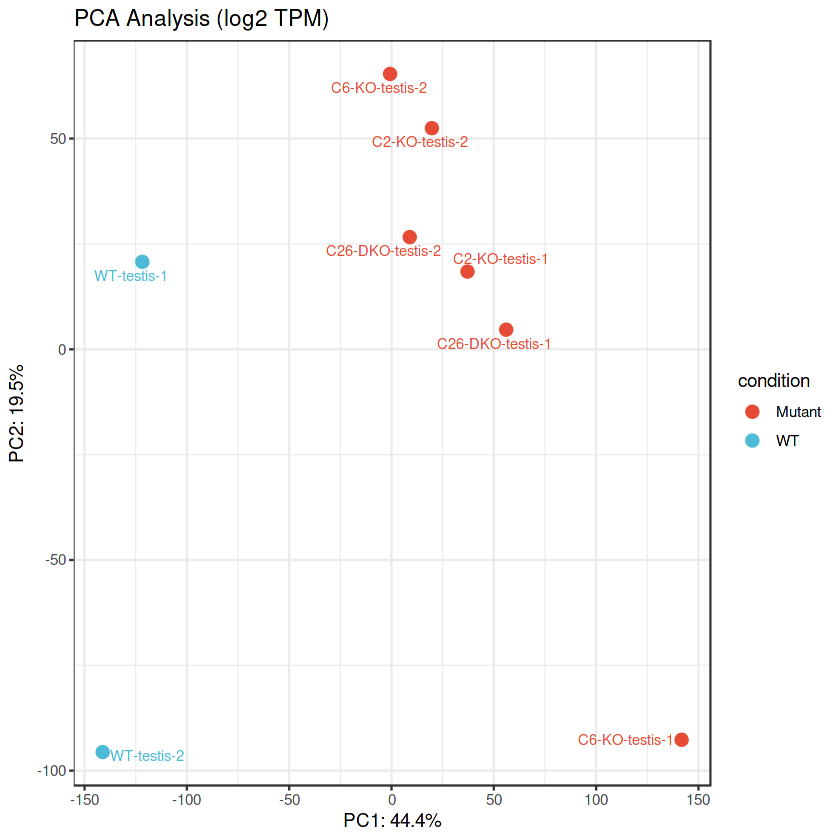

In [6]:
# 4. 计算PCA

# 准备数据
expr_pca <- as.data.frame(gene_TPM)
rownames(expr_pca) <- expr_pca[,1]
expr_pca <- expr_pca[,-1]

# log2转换（加1避免log0）
expr_log <- log2(expr_pca + 1)

# 执行PCA
pca_result <- prcomp(t(expr_log), center = TRUE, scale. = TRUE)

# 创建PCA数据框
pca_data <- as.data.frame(pca_result$x[, 1:2])
pca_data$condition <- ifelse(grepl("^WT-", rownames(pca_data)), "WT", "Mutant")
pca_data$name <- rownames(pca_data)

# 计算方差解释比例
percentVar <- round(100 * summary(pca_result)$importance[2, 1:2], 1)

# 绘图
p_pca <- ggplot(pca_data, aes(x = PC1, y = PC2, 
                               color = condition, 
                               label = name)) +
  geom_point(size = 3) + 
  geom_text_repel(size = 3, max.overlaps = 20) + 
  labs(
    x = paste0("PC1: ", percentVar[1], "%"),
    y = paste0("PC2: ", percentVar[2], "%"),
    title = "PCA Analysis (log2 TPM)"
  ) +
  scale_color_manual(values = c(WT = "#4DBBD5", Mutant = "#E64B35")) +
  theme_bw()

# 保存
dir.create("12_PCA", showWarnings = FALSE)
ggsave("12_PCA/PCA_plot.png", p_pca, width = 8, height = 6, dpi = 300)
print(p_pca)

In [7]:
# 5. 筛选差异表达基因

In [8]:
suppressMessages({
  # 确保路径和文件名完全正确
  gene_info = read_csv("./mouse_gene_info.csv", na = "NA")
})

In [9]:
# 添加gene_name
gene_counts <- gene_counts %>%
  left_join(gene_info[c("GeneID", "Gene_name")], by = c("gene_id" = "GeneID")) %>%
  relocate(Gene_name, .after = 1)

In [10]:
head(gene_counts)

gene_id,Gene_name,WT-testis-1,WT-testis-2,C6-KO-testis-2,C6-KO-testis-1,C26-DKO-testis-2,C2-KO-testis-1,C2-KO-testis-2,C26-DKO-testis-1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000000001,Gnai3,1363,1344,1811,2364,1914,1785,2019,2217
ENSMUSG00000000028,Cdc45,707,772,767,742,824,702,718,915
ENSMUSG00000000037,Scml2,738,745,845,1104,987,797,949,1007
ENSMUSG00000000049,Apoh,1010,846,743,671,886,819,873,907
ENSMUSG00000000056,Narf,155,159,218,211,194,178,206,209
ENSMUSG00000000058,Cav2,42,67,57,176,74,81,112,93


[1] "WT-testis-1"      "WT-testis-2"      "C6-KO-testis-2"   "C6-KO-testis-1"  
[5] "C26-DKO-testis-2" "C2-KO-testis-1"   "C2-KO-testis-2"   "C26-DKO-testis-1"


converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Warning message:
“Removed 4669 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4669 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3891 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3891 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4280 rows containing missing values or values outside the scale range
(`geom_point()`).”


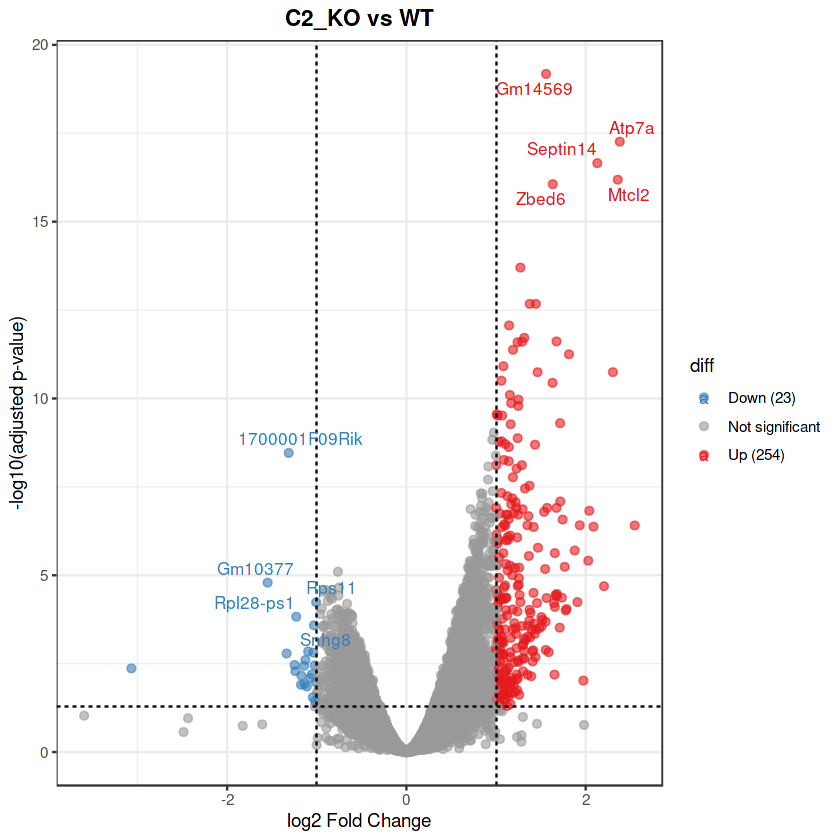

Warning message:
“Removed 4280 rows containing missing values or values outside the scale range
(`geom_point()`).”


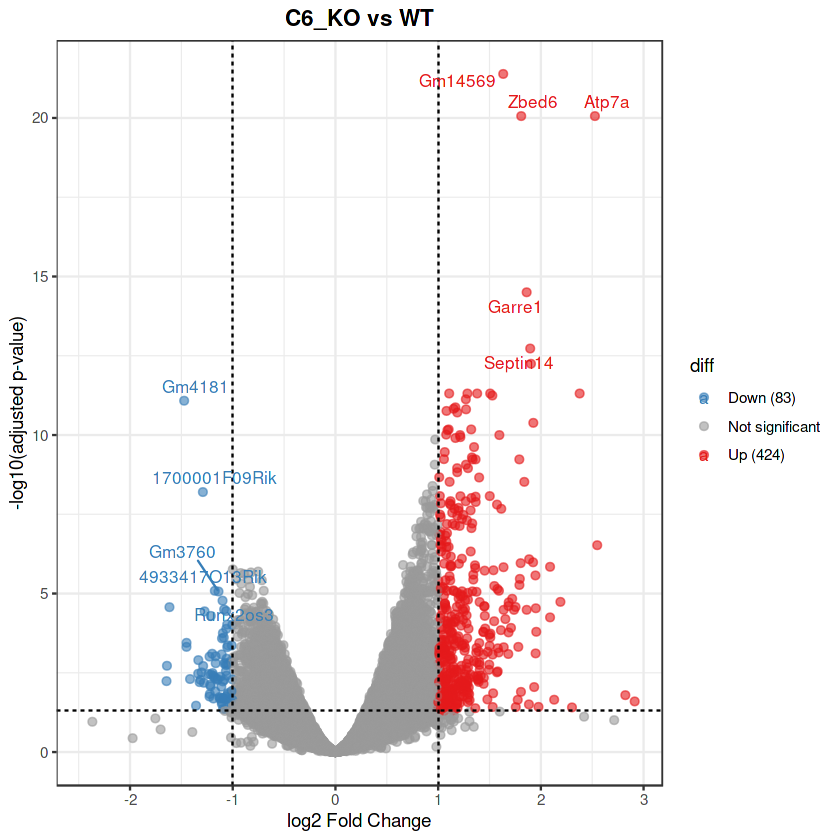

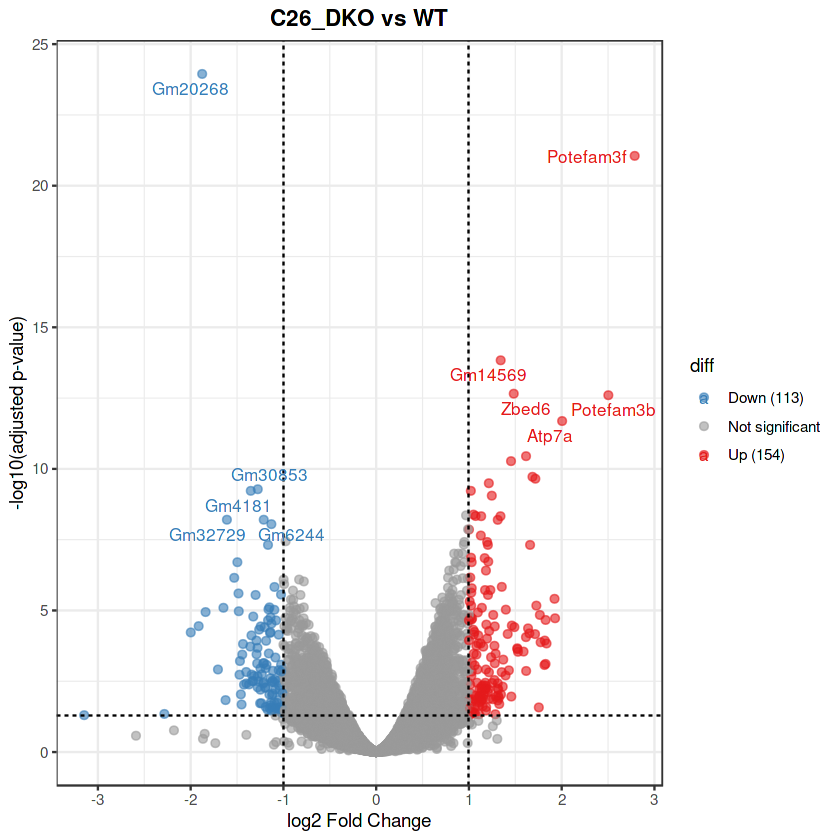

In [11]:
# 加载所需包
library(DESeq2)
library(ggplot2)
library(ggrepel)
library(dplyr)

# 创建输出目录
dir.create("./08_DE", showWarnings = FALSE)

# ---------------------------
# 1. 数据预处理
# ---------------------------
# 将gene_counts转换为标准数据框
gene_counts_df <- as.data.frame(gene_counts)

# 提取counts数据（去掉前两列：gene_id和Gene_name）
counts_data <- gene_counts_df[, 3:10]  # 第3到10列是8个样本
rownames(counts_data) <- gene_counts_df$gene_id

# 检查列名
print(colnames(counts_data))

# 构建样本分组信息
sample_info <- data.frame(
  group = factor(c("WT", "WT", "C6_KO", "C6_KO", "C26_DKO", "C2_KO", "C2_KO", "C26_DKO"),
                 levels = c("WT", "C2_KO", "C6_KO", "C26_DKO"))
)
rownames(sample_info) <- colnames(counts_data)

# ---------------------------
# 2. DESeq2 差异分析
# ---------------------------
dds <- DESeqDataSetFromMatrix(countData = counts_data, colData = sample_info, design = ~ group)
dds <- DESeq(dds)

# 提取三组比较结果
comparisons <- list(C2_KO = c("group", "C2_KO", "WT"),
                    C6_KO = c("group", "C6_KO", "WT"),
                    C26_DKO = c("group", "C26_DKO", "WT"))

for(comp in names(comparisons)) {
  # 获取结果
  res <- results(dds, contrast = comparisons[[comp]], alpha = 0.05)
  res_df <- as.data.frame(res)
  
  # 添加基因信息
  res_df$Gene_id <- rownames(res_df)
  res_df$Gene_name <- gene_counts_df$Gene_name[match(rownames(res_df), gene_counts_df$gene_id)]
  res_df$regulated <- ifelse(res_df$padj < 0.05 & abs(res_df$log2FoldChange) > 1, 
                          ifelse(res_df$log2FoldChange > 1, "up", "down"), "none")
  
  # 保存DEG列表
  deg <- res_df %>% filter(regulated != "none") %>% arrange(regulated, padj)
  write.csv(deg, file = paste0("./08_DE/DEG_", comp, "_vs_WT.csv"), row.names = FALSE)
  
  # 绘制火山图
  plot_data <- res_df %>%
    mutate(diff = case_when(padj < 0.05 & log2FoldChange > 1 ~ "Up",
                             padj < 0.05 & log2FoldChange < -1 ~ "Down",
                             TRUE ~ "Not significant"),
           diff = factor(diff, levels = c("Down", "Not significant", "Up")))
  
  up <- sum(plot_data$diff == "Up", na.rm = TRUE)
  down <- sum(plot_data$diff == "Down", na.rm = TRUE)
  
  top_genes <- plot_data %>% 
    filter(diff != "Not significant") %>% 
    arrange(padj) %>% 
    group_by(diff) %>% 
    slice_head(n = 5)
  
  p <- ggplot(plot_data, aes(x = log2FoldChange, y = -log10(padj), color = diff)) +
    geom_point(alpha = 0.6, size = 1.8) +
    scale_color_manual(values = c("Down" = "#377EB8", "Not significant" = "grey60", "Up" = "#E41A1C"),
                       labels = c(paste0("Down (", down, ")"), "Not significant", paste0("Up (", up, ")"))) +
    geom_vline(xintercept = c(-1, 1), linetype = "dashed") +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed") +
    geom_text_repel(data = top_genes, aes(label = Gene_name), size = 3.5, max.overlaps = Inf) +
    labs(title = paste0(comp, " vs WT"), 
         x = "log2 Fold Change", 
         y = "-log10(adjusted p-value)") +
    theme_bw() + 
    theme(plot.title = element_text(hjust = 0.5, face = "bold"))
  
  ggsave(filename = paste0("./08_DE/volcano_", comp, "_vs_WT.png"), plot = p, width = 8, height = 6, dpi = 300)
  print(p)
}

In [12]:
# 6. GO富集图
# 创建输出目录
dir.create("./09_GO", showWarnings = FALSE)

# 获取所有差异表达文件
deg_files <- list.files("./08_DE", pattern = "\\.csv$", full.names = TRUE)

# 遍历每个文件
for(file in deg_files) {
  
  # 提取文件名（不含路径和扩展名）
  file_name <- tools::file_path_sans_ext(basename(file))
  cat("\n处理文件:", file_name, "\n")
  
  # 创建该文件的输出子目录
  output_dir <- paste0("./09_GO/", file_name)
  dir.create(output_dir, showWarnings = FALSE)
  
  # 读取差异分析结果
  df <- read.csv(file)
  
  # 提取上调和下调的基因（使用Gene_id列）
  upregulated_genes <- df$Gene_id[df$regulated == "up"]
  downregulated_genes <- df$Gene_id[df$regulated == "down"]
  
  cat("上调基因数量:", length(upregulated_genes), "\n")
  cat("下调基因数量:", length(downregulated_genes), "\n")
  
  # 定义一个函数进行GO分析并保存结果
  run_go_analysis <- function(gene_list, direction, file_prefix) {
    
    if(length(gene_list) == 0) {
      cat(direction, ": 没有基因\n")
      return(NULL)
    }
    
    # 进行GO富集分析（三个本体）
    go_results <- list()
    
    for(ont in c("BP", "CC", "MF")) {
      ego <- enrichGO(gene = gene_list, 
                      OrgDb = org.Mm.eg.db, 
                      keyType = 'ENSEMBL', 
                      ont = ont, 
                      pvalueCutoff = 0.05, 
                      qvalueCutoff = 0.05)
      
      # 保存结果到文件
      if(!is.null(ego) && nrow(ego@result) > 0) {
        # 保存完整结果
        write.csv(as.data.frame(ego@result), 
                  file = paste0(output_dir, "/", file_prefix, "_", direction, "_", ont, "_full.csv"), 
                  row.names = FALSE)
        
        # 保存显著结果（p.adjust < 0.05）
        sig_result <- as.data.frame(ego@result) %>% filter(p.adjust < 0.05)
        if(nrow(sig_result) > 0) {
          write.csv(sig_result, 
                    file = paste0(output_dir, "/", file_prefix, "_", direction, "_", ont, "_significant.csv"), 
                    row.names = FALSE)
          
          # 绘制dotplot
          p <- dotplot(ego, showCategory = 15) + 
            ggtitle(paste0(file_prefix, " - ", direction, " - ", ont)) +
            theme(plot.title = element_text(hjust = 0.5, size = 12))
          
          ggsave(filename = paste0(output_dir, "/", file_prefix, "_", direction, "_", ont, "_dotplot.png"), 
                 plot = p, width = 10, height = 8, dpi = 300)
          
          # 绘制barplot
          p2 <- barplot(ego, showCategory = 15) + 
            ggtitle(paste0(file_prefix, " - ", direction, " - ", ont)) +
            theme(plot.title = element_text(hjust = 0.5, size = 12))
          
          ggsave(filename = paste0(output_dir, "/", file_prefix, "_", direction, "_", ont, "_barplot.png"), 
                 plot = p2, width = 10, height = 8, dpi = 300)
          
          cat(direction, "-", ont, ": 找到", nrow(sig_result), "个显著GO terms\n")
        } else {
          cat(direction, "-", ont, ": 没有显著GO terms\n")
        }
        
        go_results[[ont]] <- ego
      }
    }
    
    return(go_results)
  }
  
  # 对上调和下调基因分别进行GO分析
  run_go_analysis(upregulated_genes, "up", file_name)
  run_go_analysis(downregulated_genes, "down", file_name)
  
  cat("完成处理:", file_name, "\n")
}

cat("\n所有GO分析完成！结果保存在 ./09_GO 目录\n")


处理文件: DEG_C2_KO_vs_WT 
上调基因数量: 254 
下调基因数量: 23 
up - BP : 找到 151 个显著GO terms
up - CC : 找到 23 个显著GO terms
up - MF : 找到 38 个显著GO terms
down - BP : 找到 11 个显著GO terms
down - CC : 找到 3 个显著GO terms
down - MF : 没有显著GO terms
完成处理: DEG_C2_KO_vs_WT 

处理文件: DEG_C26_DKO_vs_WT 
上调基因数量: 154 
下调基因数量: 113 
up - BP : 没有显著GO terms
up - CC : 找到 1 个显著GO terms
up - MF : 找到 7 个显著GO terms
down - BP : 没有显著GO terms
down - CC : 没有显著GO terms
down - MF : 找到 1 个显著GO terms
完成处理: DEG_C26_DKO_vs_WT 

处理文件: DEG_C6_KO_vs_WT 
上调基因数量: 424 
下调基因数量: 83 
up - BP : 找到 544 个显著GO terms
up - CC : 找到 31 个显著GO terms
up - MF : 找到 36 个显著GO terms
down - BP : 没有显著GO terms
down - CC : 没有显著GO terms
down - MF : 没有显著GO terms
完成处理: DEG_C6_KO_vs_WT 

所有GO分析完成！结果保存在 ./09_GO 目录


In [15]:
# 7. KEGG富集图
# 创建输出目录
dir.create("./10_KEGG", showWarnings = FALSE)

# 获取所有差异表达文件
deg_files <- list.files("./08_DE", pattern = "\\.csv$", full.names = TRUE)

# 遍历每个文件
for(file in deg_files) {
  
  # 提取文件名（不含路径和扩展名）
  file_name <- tools::file_path_sans_ext(basename(file))
  cat("\n处理文件:", file_name, "\n")
  
  # 创建该文件的输出子目录
  output_dir <- paste0("./10_KEGG/", file_name)
  dir.create(output_dir, showWarnings = FALSE)
  
  # 读取差异分析结果
  df <- read.csv(file)
  
  # 提取上调和下调的基因（使用Gene_id列）
  upregulated_genes <- df$Gene_id[df$regulated == "up"]
  downregulated_genes <- df$Gene_id[df$regulated == "down"]
  
  cat("上调基因数量:", length(upregulated_genes), "\n")
  cat("下调基因数量:", length(downregulated_genes), "\n")
  
  # 定义函数进行KEGG分析并保存结果
  run_kegg_analysis <- function(gene_list, direction, file_prefix) {
    
    if(length(gene_list) == 0) {
      cat(direction, ": 没有基因\n")
      return(NULL)
    }
    
    # 将ENSEMBL ID转换为ENTREZ ID（KEGG分析需要）
    gene_entrez <- bitr(gene_list, 
                        fromType = "ENSEMBL", 
                        toType = "ENTREZID", 
                        OrgDb = org.Mm.eg.db)
    
    if(nrow(gene_entrez) == 0) {
      cat(direction, ": 没有成功转换的基因ID\n")
      return(NULL)
    }
    
    # 进行KEGG富集分析
    kk <- enrichKEGG(gene = gene_entrez$ENTREZID,
                     organism = 'mmu',  # 小鼠
                     pvalueCutoff = 0.05,
                     qvalueCutoff = 0.05)
    
    # 保存结果到文件
    if(!is.null(kk) && nrow(kk@result) > 0) {
      # 保存完整结果
      write.csv(as.data.frame(kk@result), 
                file = paste0(output_dir, "/", file_prefix, "_", direction, "_KEGG_full.csv"), 
                row.names = FALSE)
      
      # 保存显著结果（p.adjust < 0.05）
      sig_result <- as.data.frame(kk@result) %>% filter(p.adjust < 0.05)
      if(nrow(sig_result) > 0) {
        write.csv(sig_result, 
                  file = paste0(output_dir, "/", file_prefix, "_", direction, "_KEGG_significant.csv"), 
                  row.names = FALSE)
        
        # 绘制dotplot
        p <- dotplot(kk, showCategory = 15) + 
          ggtitle(paste0(file_prefix, " - ", direction, " - KEGG Pathway")) +
          theme(plot.title = element_text(hjust = 0.5, size = 12))
        
        ggsave(filename = paste0(output_dir, "/", file_prefix, "_", direction, "_KEGG_dotplot.png"), 
               plot = p, width = 10, height = 8, dpi = 300)
        
        # 绘制barplot
        p2 <- barplot(kk, showCategory = 15) + 
          ggtitle(paste0(file_prefix, " - ", direction, " - KEGG Pathway")) +
          theme(plot.title = element_text(hjust = 0.5, size = 12))
        
        ggsave(filename = paste0(output_dir, "/", file_prefix, "_", direction, "_KEGG_barplot.png"), 
               plot = p2, width = 10, height = 8, dpi = 300)
        
        # 绘制cnetplot（基因-通路网络图）
        tryCatch({
          p3 <- cnetplot(kk, showCategory = 10, 
                         foldChange = setNames(df$log2FoldChange[df$Gene_id %in% gene_list], 
                                              df$Gene_id[df$Gene_id %in% gene_list]))
          ggsave(filename = paste0(output_dir, "/", file_prefix, "_", direction, "_KEGG_cnetplot.png"), 
                 plot = p3, width = 12, height = 10, dpi = 300)
        }, error = function(e) cat("cnetplot绘制失败:", e$message, "\n"))
        
        # 绘制heatplot
        tryCatch({
          p4 <- heatplot(kk, showCategory = 10, 
                         foldChange = setNames(df$log2FoldChange[df$Gene_id %in% gene_list], 
                                              df$Gene_id[df$Gene_id %in% gene_list]))
          ggsave(filename = paste0(output_dir, "/", file_prefix, "_", direction, "_KEGG_heatplot.png"), 
                 plot = p4, width = 12, height = 10, dpi = 300)
        }, error = function(e) cat("heatplot绘制失败:", e$message, "\n"))
        
        cat(direction, "- KEGG: 找到", nrow(sig_result), "个显著通路\n")
      } else {
        cat(direction, "- KEGG: 没有显著通路\n")
      }
    } else {
      cat(direction, "- KEGG: 没有富集结果\n")
    }
    
    return(kk)
  }
  
  # 对上调和下调基因分别进行KEGG分析
  run_kegg_analysis(upregulated_genes, "up", file_name)
  run_kegg_analysis(downregulated_genes, "down", file_name)
  
  cat("完成处理:", file_name, "\n")
}

cat("\n所有KEGG分析完成！结果保存在 ./10_KEGG目录\n")


处理文件: DEG_C2_KO_vs_WT 
上调基因数量: 254 
下调基因数量: 23 


'select()' returned 1:many mapping between keys and columns

Warning message in bitr(gene_list, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“21.65% of input gene IDs are fail to map...”
Warning message in cnetplot.enrichResult(x, ...):
“Use 'color.params = list(foldChange = your_value)' instead of 'foldChange'.
 The foldChange parameter will be removed in the next version.”


up - KEGG: 找到 1 个显著通路


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(gene_list, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“30.43% of input gene IDs are fail to map...”


down - KEGG: 没有显著通路
完成处理: DEG_C2_KO_vs_WT 

处理文件: DEG_C26_DKO_vs_WT 
上调基因数量: 154 
下调基因数量: 113 


...

down - KEGG: 没有显著通路
完成处理: DEG_C26_DKO_vs_WT 

处理文件: DEG_C6_KO_vs_WT 
上调基因数量: 424 
下调基因数量: 83 


'select()' returned 1:many mapping between keys and columns

Warning message in bitr(gene_list, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“17.45% of input gene IDs are fail to map...”
Warning message in cnetplot.enrichResult(x, ...):
“Use 'color.params = list(foldChange = your_value)' instead of 'foldChange'.
 The foldChange parameter will be removed in the next version.”
Warning message:
“ggrepel: 4 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


up - KEGG: 找到 19 个显著通路


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(gene_list, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“45.78% of input gene IDs are fail to map...”
Warning message in cnetplot.enrichResult(x, ...):
“Use 'color.params = list(foldChange = your_value)' instead of 'foldChange'.
 The foldChange parameter will be removed in the next version.”


down - KEGG: 找到 1 个显著通路
完成处理: DEG_C6_KO_vs_WT 

所有KEGG分析完成！结果保存在 ./10_KEGG目录
